In [29]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


# Fitness Data Analysis: Activity, Calories & Performance

## 1. Project Overview

This project applies exploratory data analysis (EDA) techniques to fitness tracking data to explore patterns in physical activity, calorie expenditure, and performance.

The objective is to identify relationships between movement, exercise intensity, and energy expenditure, and to translate these findings into practical insights that can support healthier and more data-informed fitness decisions.

This project demonstrates foundational data analysis skills, including data preparation, visualisation, and interpretation, and reflects my preparation for further study in Data Science and AI.

This project explores how data analysis can be applied to personal fitness tracking to understand behavioural patterns and improve performance outcomes.

## 2. Problem Statement

Fitness tracking devices generate large amounts of behavioural data, but identifying meaningful patterns from this information requires structured analysis.

The aim of this project is to explore the dataset to answer key questions, including:

- How does daily activity relate to calorie expenditure?
- What patterns can be observed in exercise intensity?
- How might sedentary behaviour and active minutes influence performance?

By addressing these questions, the project demonstrates how data analysis can be used to better understand health and fitness behaviour.

In [30]:
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/dailyActivity_merged.csv")

df.head()


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819
1,1503960366,3/26/2016,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154
2,1503960366,3/27/2016,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944
3,1503960366,3/28/2016,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932
4,1503960366,3/29/2016,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886


In [31]:
df.columns


Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories'],
      dtype='object')

## 4. Data Cleaning

The dataset was prepared for analysis by loading the fitness activity data, reviewing the available variables, and checking for data quality issues such as missing values and data types.

No significant missing values were identified, indicating that the dataset is complete and suitable for further analysis. The date variable was converted into an appropriate datetime format to support time-based analysis.

In [32]:
df.head()
df.info()
df.isnull().sum()

df["ActivityDate"] = pd.to_datetime(df["ActivityDate"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        457 non-null    int64  
 1   ActivityDate              457 non-null    object 
 2   TotalSteps                457 non-null    int64  
 3   TotalDistance             457 non-null    float64
 4   TrackerDistance           457 non-null    float64
 5   LoggedActivitiesDistance  457 non-null    float64
 6   VeryActiveDistance        457 non-null    float64
 7   ModeratelyActiveDistance  457 non-null    float64
 8   LightActiveDistance       457 non-null    float64
 9   SedentaryActiveDistance   457 non-null    float64
 10  VeryActiveMinutes         457 non-null    int64  
 11  FairlyActiveMinutes       457 non-null    int64  
 12  LightlyActiveMinutes      457 non-null    int64  
 13  SedentaryMinutes          457 non-null    int64  
 14  Calories  

In [33]:
df["DayOfWeek"] = df["ActivityDate"].dt.day_name()
df[["ActivityDate", "DayOfWeek"]].head()

,ActivityDate,DayOfWeek
0,2016-03-25,Friday
1,2016-03-26,Saturday
2,2016-03-27,Sunday
3,2016-03-28,Monday
4,2016-03-29,Tuesday


## 5. Feature Engineering

In this section, new variables were created to enhance the analysis and provide deeper insights into activity behaviour.

This derived feature provides a way to compare active time relative to sedentary time, helping to reveal behavioural differences in activity levels across individuals.

Time-based features were also derived from the date variable to support analysis of behavioural patterns over time.

In [34]:
df["ActivityDate"] = pd.to_datetime(df["ActivityDate"])

df["ActiveToSedentaryRatio"] = df["VeryActiveMinutes"] / (df["SedentaryMinutes"] + 1)

df["DayOfWeek"] = df["ActivityDate"].dt.day_name()

df["Month"] = df["ActivityDate"].dt.month

df[["ActivityDate", "DayOfWeek", "Month", "ActiveToSedentaryRatio"]].head()

,ActivityDate,DayOfWeek,Month,ActiveToSedentaryRatio
0,2016-03-25,Friday,3,0.040994
1,2016-03-26,Saturday,3,0.151104
2,2016-03-27,Sunday,3,0.092409
3,2016-03-28,Monday,3,0.036078
4,2016-03-29,Tuesday,3,0.036649


A total activity metric was created by combining different levels of physical activity to better represent overall daily movement.

In [35]:
df["TotalActiveMinutes"] = (
    df["VeryActiveMinutes"] +
    df["FairlyActiveMinutes"] +
    df["LightlyActiveMinutes"]
)

In [36]:
df[["ActivityDate", "VeryActiveMinutes", "SedentaryMinutes", "ActiveToSedentaryRatio"]].head()

,ActivityDate,VeryActiveMinutes,SedentaryMinutes,ActiveToSedentaryRatio
0,2016-03-25,33,804,0.040994
1,2016-03-26,89,588,0.151104
2,2016-03-27,56,605,0.092409
3,2016-03-28,39,1080,0.036078
4,2016-03-29,28,763,0.036649


This derived feature provides a simple way to compare active time relative to sedentary time and can help reveal behavioural differences across individuals.

## 6. Exploratory Data Analysis

### 6.1 Steps and Calories

This section explores the relationship between daily step count and calorie expenditure.

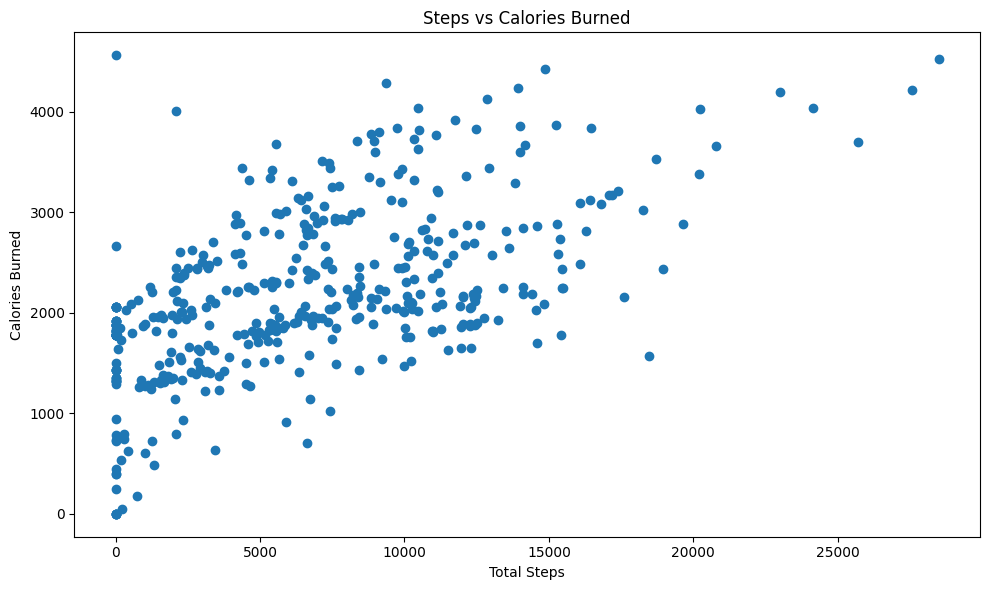

In [41]:
plt.figure(figsize=(10,6))
plt.scatter(df["TotalSteps"], df["Calories"])
plt.title("Steps vs Calories Burned")
plt.xlabel("Total Steps")
plt.ylabel("Calories Burned")
plt.tight_layout()
plt.savefig("steps_vs_calories.png", dpi=300, bbox_inches="tight")

plt.show()


**Insight:** Higher step counts are generally associated with increased calorie expenditure, suggesting a positive relationship between overall movement and energy use.

### 6.2 Distribution of Very Active Minutes

This section examines how high-intensity activity varies across individuals.

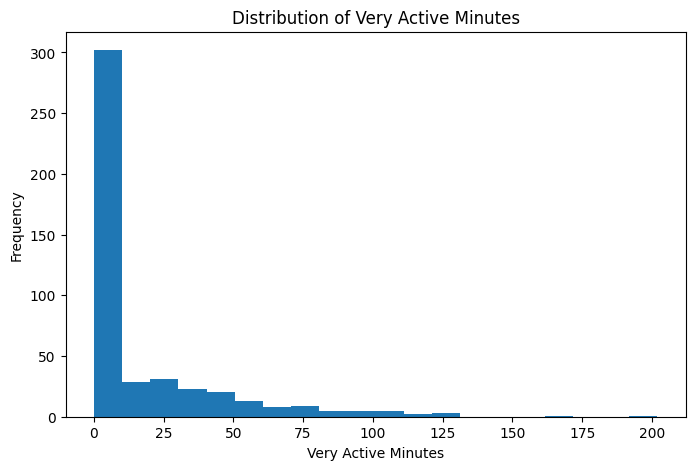

In [42]:
plt.figure(figsize=(8,5))
plt.hist(df["VeryActiveMinutes"], bins=20)
plt.title("Distribution of Very Active Minutes")
plt.xlabel("Very Active Minutes")
plt.ylabel("Frequency")
plt.savefig("very_active_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

**Insight:** The distribution is highly right-skewed, with most individuals recording low levels of very active minutes and only a small number engaging in high-intensity activity.

### 6.3 Sedentary Minutes and Calories

This section explores the relationship between sedentary behaviour and calorie expenditure.

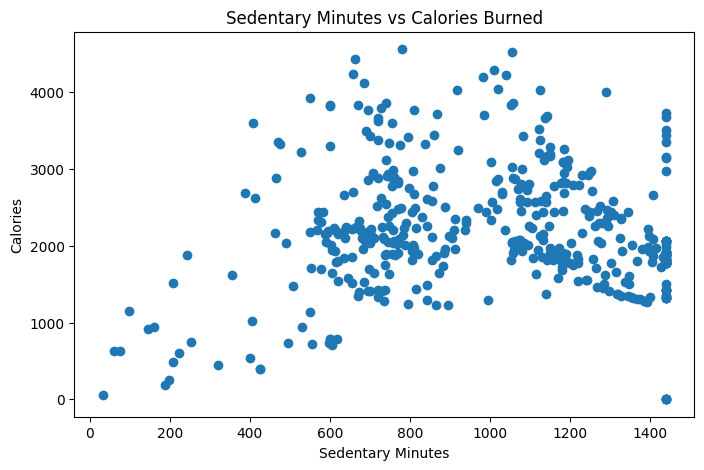

In [43]:
plt.figure(figsize=(8,5))
plt.scatter(df["SedentaryMinutes"], df["Calories"])
plt.title("Sedentary Minutes vs Calories Burned")
plt.xlabel("Sedentary Minutes")
plt.ylabel("Calories")
plt.savefig("sedentary_vs_calories.png", dpi=300, bbox_inches="tight")

plt.show()


**Insight:** There is no strong linear relationship between sedentary minutes and calorie expenditure, suggesting that inactivity alone does not determine overall energy burn.

### 6.4 Very Active Minutes and Calories

This section examines how high-intensity activity is related to calorie expenditure.

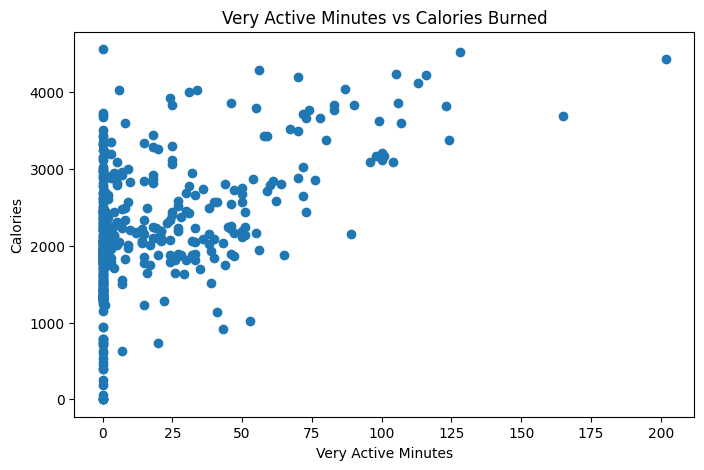

In [44]:
plt.figure(figsize=(8,5))
plt.scatter(df["VeryActiveMinutes"], df["Calories"])
plt.title("Very Active Minutes vs Calories Burned")
plt.xlabel("Very Active Minutes")
plt.ylabel("Calories")
plt.savefig("very_active_vs_calories.png", dpi=300, bbox_inches="tight")

plt.show()


**Insight:** Higher levels of very active minutes are associated with increased calorie expenditure, highlighting the importance of exercise intensity in overall performance.

In [45]:
import os
print(os.listdir("/kaggle/working"))

['sedentary_vs_calories.png', 'very_active_vs_calories.png', 'very_active_distribution.png', 'steps_vs_calories.png', '.virtual_documents']


## 7. Key Insights

 - **Physical activity is positively associated with calorie expenditure**  
  Higher step counts and very active minutes are generally linked to increased calorie burn, suggesting that both movement and exercise intensity contribute to overall energy use.

- **Exercise intensity varies significantly across individuals**  
  The distribution of very active minutes is highly skewed, indicating that most individuals engage in low levels of high-intensity activity, while only a small number perform intense workouts.

- **Sedentary behaviour alone does not determine energy expenditure**  
  The relationship between sedentary minutes and calories burned appears weak, suggesting that calorie expenditure is influenced by a combination of activity factors rather than inactivity alone.

- **Fitness tracking data reveals meaningful behavioural patterns**  
  The analysis demonstrates how wearable device data can provide insights into activity habits, supporting more informed and data-driven fitness decisions.

## 8. Recommendations

- **Improve consistency in physical activity**  
  Establishing a structured and regular workout routine can help maintain consistent activity levels and support long-term fitness progress. Participating in community-based fitness activities can improve motivation and accountability, while starting with smaller, manageable goals and gradually increasing intensity can help build sustainable habits over time.

- **Monitor both duration and intensity of workouts**  
  Tracking not only how often activity occurs, but also how intense it is, can provide a more complete understanding of performance and help optimise training outcomes. For example, wearable devices and fitness applications (e.g., Strava) enable real-time tracking of activity data, allowing individuals to monitor progress, adjust intensity, and receive feedback through shared fitness communities.

- **Leverage data for personalised fitness planning**  
  Historical activity data can be used to design tailored workout plans that align with individual fitness goals and behavioural patterns.

- **Incorporate data-driven feedback systems**  
  Fitness tracking platforms could provide real-time insights and personalised recommendations based on user activity data to improve engagement and performance.
Observing measurable improvements can reinforce positive behaviour, increase motivation, and support long-term adherence to fitness routines.

These recommendations highlight how data analysis can be used to support better decision-making and improve fitness outcomes through structured and personalised approaches.

## 9. Limitations and Future Work

This analysis is limited to exploratory analysis of fitness tracking data and does not include predictive or causal modelling. In addition, the dataset may not capture all relevant factors influencing performance, such as nutrition, sleep, or recovery.

Future work could extend this project by applying machine learning techniques to predict performance trends, identify patterns in user behaviour, and develop personalised workout recommendations. These approaches would provide deeper insights and demonstrate the potential of data science applications in health and fitness.